In [8]:
import pandas as pd

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [9]:
df = pd.read_csv("../data/processed/processed_data.csv")

In [10]:
df.shape

(73093, 52)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 73093 entries, 0 to 73092
Data columns (total 52 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     73093 non-null  str    
 1   Inventory Level          73093 non-null  int64  
 2   Units Sold               73093 non-null  int64  
 3   Units Ordered            73093 non-null  int64  
 4   Demand Forecast          73093 non-null  float64
 5   Price                    73093 non-null  float64
 6   Discount                 73093 non-null  int64  
 7   Holiday/Promotion        73093 non-null  int64  
 8   Competitor Pricing       73093 non-null  float64
 9   Year                     73093 non-null  int64  
 10  Month                    73093 non-null  int64  
 11  Day                      73093 non-null  int64  
 12  Weekday                  73093 non-null  int64  
 13  sales_lag_1              73093 non-null  float64
 14  sales_lag_7              73093 no

In [12]:
df.select_dtypes(include="object").columns

C:\Users\pooja\AppData\Local\Temp\ipykernel_13304\1196084386.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include="object").columns


Index(['Date'], dtype='str')

In [13]:
df["Date"] = pd.to_datetime(df["Date"])

In [15]:
y = df["Units Sold"]


X = df.drop(
    columns=[
        "Units Sold",
        "Date",
        "Demand Forecast"
    ]
)

In [16]:
print(X.shape)
print("Demand Forecast" in X.columns)

(73093, 49)
False


In [17]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]


In [20]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [21]:
y_pred = model.predict(X_test)

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae}")
print(f"Root Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Absolute Error: 65.12946441271094
Root Mean Squared Error: 82.5308767359748
R-squared: 0.418645533956713


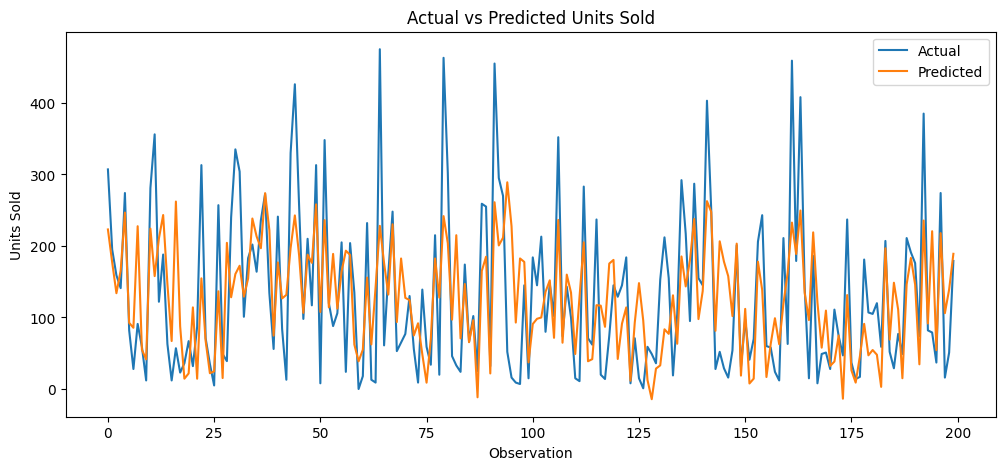

<Figure size 640x480 with 0 Axes>

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(y_test.values[:200], label="Actual")
plt.plot(y_pred[:200], label="Predicted")

plt.title("Actual vs Predicted Units Sold")
plt.xlabel("Observation")
plt.ylabel("Units Sold")
plt.legend()

plt.show()

plt.savefig("../reports/figures/actual_vs_predicted.png")